# ECG Multi-class Classification using 1D-CNN + Bi-LSTM
**Approach:** Hybrid Deep Learning (1D Convolutions for spatial features + Bidirectional LSTM for temporal dependencies).
**Protocol:** Inter-patient split according to De Chazal (2004), excluding Class P (Paced Beats).

## 1. Environment Setup and Dependencies
In this section, we install the necessary `wfdb` library to read the MIT-BIH Arrhythmia database records, import essential scientific packages, and configure the random seeds to ensure deterministic and reproducible outputs across multiple runs.

In [1]:
!pip install wfdb --no-dependencies

import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

import wfdb
from scipy.signal import butter, filtfilt
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


## 2. Data Downloading
This section automates the downloading of the MIT-BIH Arrhythmia Database from PhysioNet. It downloads both the signal files (.dat) and the professional annotation files (.atr) required for training and testing.

In [2]:
import urllib.request

DATA_DIR = './mitbih_data'
os.makedirs(DATA_DIR, exist_ok=True)

records = [
    100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 121, 122, 123, 124,
    200, 201, 202, 203, 205, 207, 208, 209, 210, 212, 213, 214, 215, 217, 219, 220, 221, 222, 223, 228, 230, 231, 232, 233, 234
]

print("Downloading MIT-BIH Arrhythmia Database records...")
for r in tqdm(records):
    for ext in ['dat', 'hea', 'atr']:
        file_name = f"{r}.{ext}"
        file_path = os.path.join(DATA_DIR, file_name)
        if not os.path.exists(file_path):
            url = f"https://physionet.org/files/mitdb/1.0.0/{file_name}"
            try:
                urllib.request.urlretrieve(url, file_path)
            except Exception as e:
                print(f"Failed to download {url}: {e}")
print("Download completed or verified.")

100%|██████████| 48/48 [10:47<00:00, 13.50s/it]

Download completed or verified.


## 3. Signal Preprocessing (Bandpass Filtering)
ECG signals are often corrupted by baseline wander (low frequency) and powerline interference or muscle artifacts (high frequency). Here we apply a Butterworth digital bandpass filter (0.5 Hz to 35 Hz) to clean Lead II signals before heartbeat extraction.

In [3]:
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut=0.5, highcut=35.0, fs=360, order=3):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

## 4. Patient Grouping (De Chazal Inter-patient Split Paradigm) & Exclude P-Class
To build a clinically robust model, we must avoid data leakage by performing an inter-patient split rather than an intra-patient split. Following De Chazal (2004), patient records are strictly divided into DS1 (Train) and DS2 (Test) groups. In this section, we define the clinical mappings into standard AAMI classes (N, S, V, F) and strictly exclude the P (Paced) beats class, as paced heartbeats are governed by artificial pacemakers.

In [4]:
# De Chazal (2004) Group Splits
DS1_records = [101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230]
DS2_records = [100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210, 212, 213, 214, 217, 219, 221, 222, 228, 231, 232, 233, 234]

# AAMI Class Mappings
AAMI_MAPPING = {
    'N': ['N', 'L', 'R', 'e', 'j'],              # Normal/Bundle branch block beats
    'S': ['A', 'a', 'J', 'S'],                   # Supraventricular ectopic beats
    'V': ['V', 'E'],                             # Ventricular ectopic beats
    'F': ['F'],                                  # Fusion beats
    'P': ['/', 'f', 'Q']                         # Paced / Unclassifiable beats (to be removed)
}

CLASS_TO_IDX = {'N': 0, 'S': 1, 'V': 2, 'F': 3}
IDX_TO_CLASS = {0: 'N', 1: 'S', 2: 'V', 3: 'F'}

def get_aami_label(symbol):
    for aami_cls, symbols in AAMI_MAPPING.items():
        if symbol in symbols:
            return aami_cls
    return None

## 5. Heartbeat Segmentation & Dataset Preparation
This section extracts individual heartbeats around annotated R-peaks. For each valid annotation, we take a window of 180 samples (90 samples before the R-peak and 90 samples after). Any heartbeat categorized as class 'P' is completely omitted from both the training and test collections.

In [5]:
def load_and_segment_dataset(record_list, data_dir='./mitbih_data', window_size=180):
    X, y = [], []
    half_win = window_size // 2
    
    for rec in record_list:
        path = os.path.join(data_dir, str(rec))
        record = wfdb.rdrecord(path)
        sig_name_list = [name.upper() for name in record.sig_name]
        ch_idx = sig_name_list.index('MLII') if 'MLII' in sig_name_list else 0
        signal = record.p_signal[:, ch_idx]
        
        filtered_signal = bandpass_filter(signal, lowcut=0.5, highcut=35.0, fs=360)
        annotation = wfdb.rdann(path, 'atr')
        
        for idx, sample_pos in enumerate(annotation.sample):
            symbol = annotation.symbol[idx]
            aami_cat = get_aami_label(symbol)
            
            if aami_cat is None or aami_cat == 'P':
                continue
                
            if sample_pos - half_win >= 0 and sample_pos + half_win < len(filtered_signal):
                segment = filtered_signal[sample_pos - half_win : sample_pos + half_win]
                
                if np.std(segment) > 0:
                    segment = (segment - np.mean(segment)) / np.std(segment)
                
                X.append(segment)
                y.append(CLASS_TO_IDX[aami_cat])
                
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

print("Loading and processing Train Set (DS1)...")
X_train, y_train = load_and_segment_dataset(DS1_records, data_dir=DATA_DIR)
print("Loading and processing Test Set (DS2)...")
X_test, y_test = load_and_segment_dataset(DS2_records, data_dir=DATA_DIR)

print(f"\nDS1 Train shape: {X_train.shape}, Class distribution: {Counter(y_train)}")
print(f"DS2 Test shape: {X_test.shape}, Class distribution: {Counter(y_test)}")

Loading and processing Train Set (DS1)...
Loading and processing Test Set (DS2)...

DS1 Train shape: (51002, 180), Class distribution: Counter({np.int64(0): 45856, np.int64(2): 3788, np.int64(1): 944, np.int64(3): 414})
DS2 Test shape: (50097, 180), Class distribution: Counter({np.int64(0): 44490, np.int64(2): 3382, np.int64(1): 1837, np.int64(3): 388})


## 6. PyTorch DataLoaders and Imbalance Handling
To tackle the intense class imbalance, we compute dynamic loss weights based on the class frequencies in the training distribution. This penalizes the network heavily when missing rare beats. We also wrap datasets inside PyTorch DataLoaders.

In [6]:
X_train_t = torch.tensor(X_train).unsqueeze(1)
y_train_t = torch.tensor(y_train)
X_test_t = torch.tensor(X_test).unsqueeze(1)
y_test_t = torch.tensor(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

counts = Counter(y_train)
total_samples = len(y_train)
num_classes = 4
class_weights = [total_samples / (num_classes * counts[i]) for i in range(num_classes)]
class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Calculated Class Weights for CrossEntropyLoss: {class_weights}")

Calculated Class Weights for CrossEntropyLoss: [0.2780552163293789, 13.506885593220339, 3.366024287222809, 30.79830917874396]


## 7. Model Architecture Definition (1D-CNN + Bi-LSTM)
Here we build the proposed alternative architecture. It features 1D Convolutional blocks to distill spatial/morphological local features, instantly followed by a Bidirectional LSTM network to model the long-range time-dependent sequence relationships across the extracted feature space.

In [7]:
class ECG_CNN_BiLSTM(nn.Module):
    def __init__(self, num_classes=4):
        super(ECG_CNN_BiLSTM, self).__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, stride=1, padding=4),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        self.lstm = nn.LSTM(input_size=32, hidden_size=64, num_layers=2,
                            batch_first=True, bidirectional=True, dropout=0.3)
        
        self.fc = nn.Sequential(
            nn.Linear(64 * 2, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

model = ECG_CNN_BiLSTM(num_classes=4).to(DEVICE)
print(model)

ECG_CNN_BiLSTM(
  (cnn): Sequential(
    (0): Conv1d(1, 16, kernel_size=(9,), stride=(1,), padding=(4,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=4, bias=True)
  )
)


## 8. Training Loop with Gradient Clipping
This section sets up the training loop configuration. We leverage the calculated class weights to compute the loss and integrate standard Gradient Clipping (`clip_grad_norm_`) to prevent exploding gradients and enforce stable tracking throughout the LSTM layers.

In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
EPOCHS = 15

print("Starting Model Training...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch}/{EPOCHS}] - Loss: {epoch_loss:.4f}")

Starting Model Training...
Epoch [1/15] - Loss: 1.0062
Epoch [2/15] - Loss: 0.7429
Epoch [3/15] - Loss: 0.5783
Epoch [4/15] - Loss: 0.5040
Epoch [5/15] - Loss: 0.4473
Epoch [6/15] - Loss: 0.3991
Epoch [7/15] - Loss: 0.3761
Epoch [8/15] - Loss: 0.3558
Epoch [9/15] - Loss: 0.3185
Epoch [10/15] - Loss: 0.3069
Epoch [11/15] - Loss: 0.3032
Epoch [12/15] - Loss: 0.2611
Epoch [13/15] - Loss: 0.2716
Epoch [14/15] - Loss: 0.2528
Epoch [15/15] - Loss: 0.2582


## 9. Model Evaluation and Performance Metrics
In this final section, we put the trained network into evaluation mode, predict labels on the unseen inter-patient test split (DS2), and print out the complete classification report detailing Precision, Recall, Macro F1-score, and the structural Confusion Matrix.


--- CLASSIFICATION REPORT (DS2 - Test Set) ---
              precision    recall  f1-score   support

           N       0.95      0.68      0.80     44490
           S       0.02      0.12      0.04      1837
           V       0.38      0.91      0.53      3382
           F       0.00      0.00      0.00       388

    accuracy                           0.67     50097
   macro avg       0.34      0.43      0.34     50097
weighted avg       0.87      0.67      0.74     50097

--- CONFUSION MATRIX ---


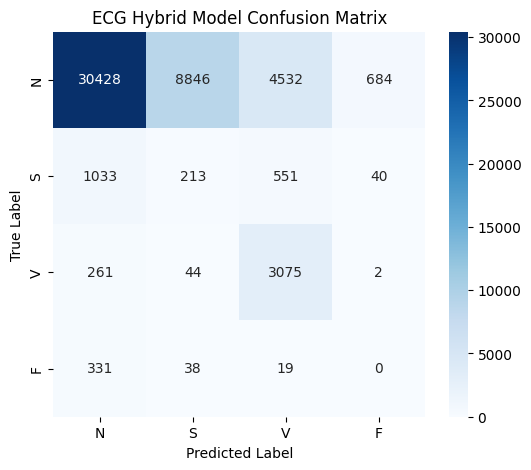

In [9]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

target_names = [IDX_TO_CLASS[i] for i in range(num_classes)]
print("\n--- CLASSIFICATION REPORT (DS2 - Test Set) ---")
print(classification_report(all_targets, all_preds, target_names=target_names))

print("--- CONFUSION MATRIX ---")
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('ECG Hybrid Model Confusion Matrix')
plt.show()